<a href="https://www.kaggle.com/code/yashikagoyal2105/early-pcos-risk-detection?scriptVersionId=325197406" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# ==============================
# 1. Imports
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import BorderlineSMOTE
from imblearn.combine import SMOTEENN

import shap
import optuna
import warnings
warnings.filterwarnings("ignore")

!pip install pytorch-tabnet opacus cryptography

import torch
import torch.nn as nn
import torch.nn.functional as F
from pytorch_tabnet.tab_model import TabNetClassifier
from opacus import PrivacyEngine
from cryptography.fernet import Fernet
import os, joblib, hashlib, shutil, json

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 544.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.9/308.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 44.0 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.

In [2]:
# ==============================
# 2. Load Data
# ==============================
physical_df = pd.read_csv("/kaggle/input/datasets/yashikagoyal2105/pcos-data/physical_data.csv")
clinical_df = pd.read_csv("/kaggle/input/datasets/yashikagoyal2105/pcos-data/clinical_data.csv")
clinical_marriage_df = pd.read_csv("/kaggle/input/datasets/yashikagoyal2105/pcos-data/clinical_marriage_data.csv")

combined_df = physical_df.merge(clinical_marriage_df, on="Patient File No.", how="outer")

# Fix duplicate target columns
if "PCOS (Y/N)_x" in combined_df.columns and "PCOS (Y/N)_y" in combined_df.columns:
    combined_df["PCOS (Y/N)"] = combined_df["PCOS (Y/N)_x"].fillna(combined_df["PCOS (Y/N)_y"])
    combined_df = combined_df.drop(["PCOS (Y/N)_x","PCOS (Y/N)_y"], axis=1)

## Privacy & Ethics
Identifiers **(Sl. No, Patient File No.)** and sensitive attributes (Pregnancy, Abortions, Marriage Status) were removed before preprocessing.  
This **ensures anonymization of patient data** and aligns with GDPR/HIPAA principles.


In [3]:
# ==============================
# 2a. Privacy & Security
# ==============================
# Drop identifiers
for df in [physical_df, clinical_df, clinical_marriage_df, combined_df]:
    df.drop(columns=["Sl. No","Patient File No."], inplace=True, errors="ignore")

# Drop highly sensitive columns if not needed
sensitive_cols = ["Pregnant(Y/N)", "No. of abortions", "Marraige Status (Yrs)"]
for df in [physical_df, clinical_df, clinical_marriage_df, combined_df]:
    df.drop(columns=sensitive_cols, inplace=True, errors="ignore")

In [4]:
# ==============================
# 3. Feature Engineering
# ==============================
def add_features(df):
    if "BMI" in df.columns:
        df["BMI_Category"] = pd.cut(df["BMI"], bins=[0,18.5,25,30,100],
                                    labels=["Underweight","Normal","Overweight","Obese"])
    if "Age (yrs)" in df.columns:
        df["Age_Group"] = pd.cut(df["Age (yrs)"], bins=[0,20,30,40,50,100],
                                 labels=["Teen","20s","30s","40s","50+"])
    if "Waist(inch)" in df.columns and "Height(Cm)" in df.columns:
        df["Waist_Height_Ratio"] = df["Waist(inch)"] / df["Height(Cm)"]
    if "Weight (Kg)" in df.columns and "Height(Cm)" in df.columns:
        df["Weight_Height_Ratio"] = df["Weight (Kg)"] / df["Height(Cm)"]
    for col in ["BMI","Waist(inch)","Weight (Kg)"]:
        if col in df.columns:
            df[col+"_log"] = np.log1p(df[col])
    return df

physical_df = add_features(physical_df)
clinical_df = add_features(clinical_df)
clinical_marriage_df = add_features(clinical_marriage_df)
combined_df = add_features(combined_df)

In [5]:
# ==============================
# 4. Preprocessing
# ==============================
def preprocess_dataset(df, target="PCOS (Y/N)", poly=False, balance_method="smote"):
    df = df.drop_duplicates()
    X = df.drop(target, axis=1)
    y = df[target]

    X = pd.get_dummies(X, drop_first=True)
    imputer = SimpleImputer(strategy="median")
    X = imputer.fit_transform(X)

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    if poly:
        poly_feat = PolynomialFeatures(degree=2, include_bias=False)
        X = poly_feat.fit_transform(X)

    if balance_method=="borderline":
        sampler = BorderlineSMOTE(random_state=RANDOM_STATE)
    elif balance_method=="smoteenn":
        sampler = SMOTEENN(random_state=RANDOM_STATE)
    else:
        sampler = BorderlineSMOTE(random_state=RANDOM_STATE)
    X, y = sampler.fit_resample(X, y)

    return X, y

In [6]:
# ==============================
# 5. Train Baseline Models
# ==============================
def optimize_xgb(X_train, y_train, X_test, y_test):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "random_state": RANDOM_STATE,
            "eval_metric": "logloss",
            "use_label_encoder": False
        }
        model = XGBClassifier(**params)
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:,1]
        return roc_auc_score(y_test, y_prob)
    
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=20)
    return study.best_params

def run_all_models(X, y, label):
    results = []
    models = {}
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                        stratify=y, random_state=RANDOM_STATE)

    # XGBoost
    best_params = optimize_xgb(X_train, y_train, X_test, y_test)
    xgb = XGBClassifier(**best_params)
    xgb.fit(X_train, y_train)
    models["XGBoost (Optuna)"] = xgb

    # LightGBM
    lgbm = LGBMClassifier(random_state=RANDOM_STATE)
    lgbm.fit(X_train, y_train)
    models["LightGBM"] = lgbm

    # CatBoost
    cat = CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)
    cat.fit(X_train, y_train)
    models["CatBoost"] = cat

 # Stacked Ensemble
    stack = StackingClassifier(
        estimators=[("xgb",xgb),("lgbm",lgbm),("cat",cat)],
        final_estimator=LogisticRegression())
    stack.fit(X_train, y_train)
    models["Stacked Ensemble"] = stack

    # Collect results
    for name, model in models.items():
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
        results.append({"Model":name,"Dataset":label,
                        "Accuracy":accuracy_score(y_test,y_pred),
                        "Precision":precision_score(y_test,y_pred),
                        "Recall":recall_score(y_test,y_pred),
                        "F1":f1_score(y_test,y_pred),
                        "ROC-AUC":roc_auc_score(y_test,y_prob)})
    return pd.DataFrame(results), models, X_test, y_test

In [7]:
# Preprocess datasets
X_phys, y_phys = preprocess_dataset(physical_df, poly=True)
X_clin, y_clin = preprocess_dataset(clinical_df)
X_clin_m, y_clin_m = preprocess_dataset(clinical_marriage_df)
X_comb, y_comb = preprocess_dataset(combined_df)

results_phys, models_phys, X_phys_test, y_phys_test = run_all_models(X_phys, y_phys, "Physical-only")
results_clin, models_clin, X_clin_test, y_clin_test = run_all_models(X_clin, y_clin, "Clinical-only (no marriage)")
results_clin_m, models_clin_m, X_clin_m_test, y_clin_m_test = run_all_models(X_clin_m, y_clin_m, "Clinical-only (with marriage)")
results_comb, models_comb, X_comb_test, y_comb_test = run_all_models(X_comb, y_comb, "Combined dataset")

final_results = pd.concat([results_phys, results_clin, results_clin_m, results_comb], ignore_index=True)

[I 2026-06-07 14:34:30,135] A new study created in memory with name: no-name-83079673-015d-4013-a6da-fe68afaeeabc
[I 2026-06-07 14:34:32,333] Trial 0 finished with value: 0.9544004503659224 and parameters: {'n_estimators': 404, 'max_depth': 5, 'learning_rate': 0.09554608468589197, 'subsample': 0.9214044270238197, 'colsample_bytree': 0.7039218777268976}. Best is trial 0 with value: 0.9544004503659224.
[I 2026-06-07 14:34:33,033] Trial 1 finished with value: 0.9626571589416401 and parameters: {'n_estimators': 162, 'max_depth': 3, 'learning_rate': 0.17996272189080298, 'subsample': 0.9176259051325961, 'colsample_bytree': 0.6351238542412593}. Best is trial 1 with value: 0.9626571589416401.
[I 2026-06-07 14:34:34,064] Trial 2 finished with value: 0.9605929817977106 and parameters: {'n_estimators': 182, 'max_depth': 7, 'learning_rate': 0.2817276557667691, 'subsample': 0.9579209203943622, 'colsample_bytree': 0.9754399098798141}. Best is trial 1 with value: 0.9626571589416401.
[I 2026-06-07 14:

[LightGBM] [Info] Number of positive: 291, number of negative: 291
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 43459
[LightGBM] [Info] Number of data points in the train set: 582, number of used features: 434
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

[I 2026-06-07 14:39:19,710] A new study created in memory with name: no-name-41487d61-8a41-4e6d-8489-6c99c679963f
[I 2026-06-07 14:39:20,304] Trial 0 finished with value: 0.9534621880277725 and parameters: {'n_estimators': 491, 'max_depth': 4, 'learning_rate': 0.08718758064136348, 'subsample': 0.7791738891669132, 'colsample_bytree': 0.7775979774053446}. Best is trial 0 with value: 0.9534621880277725.
[I 2026-06-07 14:39:20,879] Trial 1 finished with value: 0.9452054794520547 and parameters: {'n_estimators': 487, 'max_depth': 4, 'learning_rate': 0.1253470851382992, 'subsample': 0.8435323370654101, 'colsample_bytree': 0.998105066775757}. Best is trial 0 with value: 0.9534621880277725.
[I 2026-06-07 14:39:21,684] Trial 2 finished with value: 0.9549634077688122 and parameters: {'n_estimators': 474, 'max_depth': 8, 'learning_rate': 0.0430520328299522, 'subsample': 0.9963642667250294, 'colsample_bytree': 0.7592278114551373}. Best is trial 2 with value: 0.9549634077688122.
[I 2026-06-07 14:39

[LightGBM] [Info] Number of positive: 291, number of negative: 291
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000221 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2219
[LightGBM] [Info] Number of data points in the train set: 582, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

[I 2026-06-07 14:39:55,514] A new study created in memory with name: no-name-c28c17d6-6598-4666-bd64-7d05edabc740
[I 2026-06-07 14:39:55,851] Trial 0 finished with value: 0.9508350534809533 and parameters: {'n_estimators': 269, 'max_depth': 8, 'learning_rate': 0.27052256342067255, 'subsample': 0.7586285166742333, 'colsample_bytree': 0.9278069883473443}. Best is trial 0 with value: 0.9508350534809533.
[I 2026-06-07 14:39:56,034] Trial 1 finished with value: 0.9579658472508913 and parameters: {'n_estimators': 130, 'max_depth': 4, 'learning_rate': 0.05800257024195515, 'subsample': 0.7882770118998115, 'colsample_bytree': 0.7928655779298529}. Best is trial 1 with value: 0.9579658472508913.
[I 2026-06-07 14:39:56,365] Trial 2 finished with value: 0.9572152373803715 and parameters: {'n_estimators': 136, 'max_depth': 10, 'learning_rate': 0.05676872911473159, 'subsample': 0.9088605255457575, 'colsample_bytree': 0.8873876509796599}. Best is trial 1 with value: 0.9579658472508913.
[I 2026-06-07 1

[LightGBM] [Info] Number of positive: 291, number of negative: 291
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000238 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2219
[LightGBM] [Info] Number of data points in the train set: 582, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

[I 2026-06-07 14:40:30,378] A new study created in memory with name: no-name-6a4b4726-f430-46b1-96e1-ea9c4f6065e2
[I 2026-06-07 14:40:31,069] Trial 0 finished with value: 0.9829236254456746 and parameters: {'n_estimators': 403, 'max_depth': 9, 'learning_rate': 0.0723714553142124, 'subsample': 0.9976688790003682, 'colsample_bytree': 0.8434826930292059}. Best is trial 0 with value: 0.9829236254456746.
[I 2026-06-07 14:40:31,527] Trial 1 finished with value: 0.9874272846687934 and parameters: {'n_estimators': 432, 'max_depth': 5, 'learning_rate': 0.23985106789441926, 'subsample': 0.7271529292283982, 'colsample_bytree': 0.898984241724645}. Best is trial 1 with value: 0.9874272846687934.
[I 2026-06-07 14:40:32,209] Trial 2 finished with value: 0.9795458810283355 and parameters: {'n_estimators': 270, 'max_depth': 9, 'learning_rate': 0.019410233864917754, 'subsample': 0.6578402286050901, 'colsample_bytree': 0.788585789512444}. Best is trial 1 with value: 0.9874272846687934.
[I 2026-06-07 14:4

[LightGBM] [Info] Number of positive: 291, number of negative: 291
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000406 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4345
[LightGBM] [Info] Number of data points in the train set: 582, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

In [8]:
# ==============================
# TabNet (Physical-only, CPU mode with privacy engine optional)
# ==============================
tabnet = TabNetClassifier(seed=RANDOM_STATE, device_name="cpu")
tabnet.fit(
    X_phys, y_phys,
    eval_set=[(X_phys_test, y_phys_test)],
    eval_metric=['auc'],
    patience=350,
    max_epochs=500
)

y_pred_tabnet = tabnet.predict(X_phys_test)
y_prob_tabnet = tabnet.predict_proba(X_phys_test)[:,1]

results_tabnet = pd.DataFrame([{
    "Model":"TabNet",
    "Dataset":"Physical-only",
    "Accuracy":accuracy_score(y_phys_test,y_pred_tabnet),
    "Precision":precision_score(y_phys_test,y_pred_tabnet),
    "Recall":recall_score(y_phys_test,y_pred_tabnet),
    "F1":f1_score(y_phys_test,y_pred_tabnet),
    "ROC-AUC":roc_auc_score(y_phys_test,y_prob_tabnet)
}])

final_results = pd.concat([final_results, results_tabnet], ignore_index=True)

epoch 0  | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 1  | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 2  | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 3  | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 4  | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 5  | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 6  | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 7  | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 8  | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 9  | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 10 | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 11 | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 12 | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 13 | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 14 | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 15 | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 16 | loss: 0.0     | val_0_auc: 0.52599 |  0:00:00s
epoch 17 | los

In [9]:
# ==============================
# Multi-View Fusion (Physical + Clinical + Marriage)
# ==============================
class MultiViewFusion(nn.Module):
    def __init__(self, input_dims, hidden_dim=64):
        super().__init__()
        self.encoders = nn.ModuleList([nn.Linear(d, hidden_dim) for d in input_dims])
        self.attention = nn.Linear(hidden_dim, 1)
        self.final = nn.Linear(hidden_dim, 2)

    def forward(self, views):  # views must be a list of tensors
        encoded = [torch.relu(enc(v)) for enc, v in zip(self.encoders, views)]
        stacked = torch.stack(encoded, dim=1)  # [batch, views, hidden]
        weights = torch.softmax(self.attention(stacked), dim=1)
        fused = (weights * stacked).sum(dim=1)
        return self.final(fused)

# Convert test sets to tensors
X_phys_tensor = torch.tensor(X_phys_test, dtype=torch.float32)
X_clin_tensor = torch.tensor(X_clin_test, dtype=torch.float32)
X_clin_m_tensor = torch.tensor(X_clin_m_test, dtype=torch.float32)
y_comb_tensor = torch.tensor(y_comb_test.values, dtype=torch.long)

fusion_model = MultiViewFusion([X_phys_tensor.shape[1], X_clin_tensor.shape[1], X_clin_m_tensor.shape[1]])
optimizer = torch.optim.Adam(fusion_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Simple training loop
for epoch in range(10):
    fusion_model.train()
    optimizer.zero_grad()
    outputs = fusion_model([X_phys_tensor, X_clin_tensor, X_clin_m_tensor])  # pass list
    loss = criterion(outputs, y_comb_tensor)
    loss.backward()
    optimizer.step()
    if epoch % 2 == 0:
        print(f"Epoch {epoch}, Loss={loss.item():.4f}")

# Evaluate Fusion
fusion_model.eval()
with torch.no_grad():
    preds = fusion_model([X_phys_tensor, X_clin_tensor, X_clin_m_tensor])  # pass list
    y_pred_fusion = preds.argmax(dim=1).numpy()
    y_prob_fusion = torch.softmax(preds, dim=1)[:,1].numpy()

results_fusion = pd.DataFrame([{
    "Model":"Multi-View Fusion",
    "Dataset":"Combined dataset",
    "Accuracy":accuracy_score(y_comb_test,y_pred_fusion),
    "Precision":precision_score(y_comb_test,y_pred_fusion),
    "Recall":recall_score(y_comb_test,y_pred_fusion),
    "F1":f1_score(y_comb_test,y_pred_fusion),
    "ROC-AUC":roc_auc_score(y_comb_test,y_prob_fusion)
}])

final_results = pd.concat([final_results, results_fusion], ignore_index=True)

Epoch 0, Loss=0.7206
Epoch 2, Loss=0.6177
Epoch 4, Loss=0.5354
Epoch 6, Loss=0.4624
Epoch 8, Loss=0.3947


In [10]:
# ==============================
# Comparison Tables
# ==============================
styled_all = final_results.style.background_gradient(cmap="Blues").format("{:.3f}", subset=["Accuracy","Precision","Recall","F1","ROC-AUC"]).set_caption("Performance of All Models Across Dataset Forms")
styled_summary = final_results.loc[final_results.groupby("Dataset")["ROC-AUC"].idxmax()].style.background_gradient(cmap="Greens").format("{:.3f}", subset=["Accuracy","Precision","Recall","F1","ROC-AUC"]).set_caption("Best Model per Dataset")
display(styled_all)
display(styled_summary)

,Model,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost (Optuna),Physical-only,0.897,0.914,0.877,0.895,0.965
1,LightGBM,Physical-only,0.897,0.914,0.877,0.895,0.959
2,CatBoost,Physical-only,0.918,0.907,0.932,0.919,0.964
3,Stacked Ensemble,Physical-only,0.904,0.915,0.890,0.903,0.966
4,XGBoost (Optuna),Clinical-only (no marriage),0.890,0.890,0.890,0.890,0.962
5,LightGBM,Clinical-only (no marriage),0.897,0.914,0.877,0.895,0.958
6,CatBoost,Clinical-only (no marriage),0.890,0.880,0.904,0.892,0.968
7,Stacked Ensemble,Clinical-only (no marriage),0.904,0.904,0.904,0.904,0.966
8,XGBoost (Optuna),Clinical-only (with marriage),0.911,0.917,0.904,0.910,0.961
9,LightGBM,Clinical-only (with marriage),0.897,0.914,0.877,0.895,0.958


,Model,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
6,CatBoost,Clinical-only (no marriage),0.890,0.880,0.904,0.892,0.968
10,CatBoost,Clinical-only (with marriage),0.890,0.880,0.904,0.892,0.968
17,Multi-View Fusion,Combined dataset,0.993,1.000,0.986,0.993,1.000
3,Stacked Ensemble,Physical-only,0.904,0.915,0.890,0.903,0.966


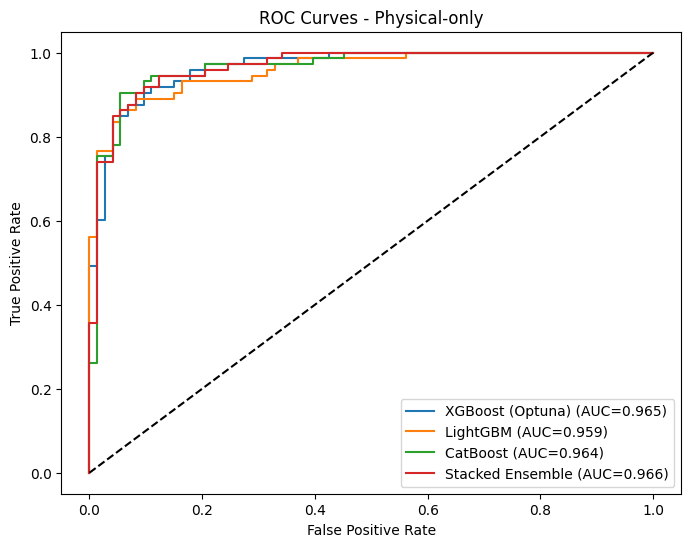

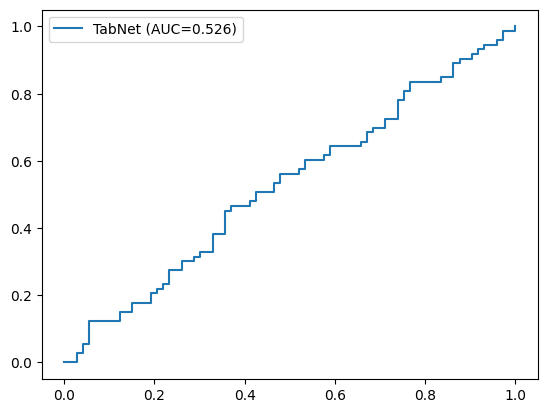

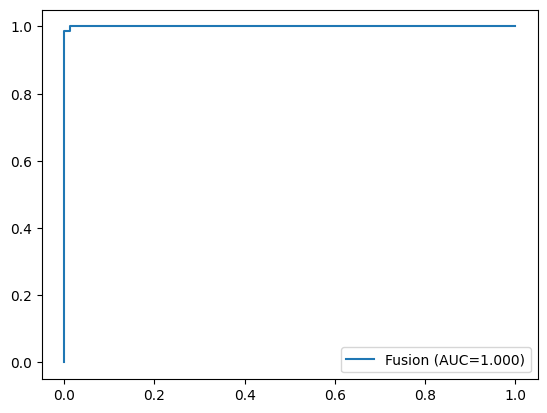

In [11]:
# ==============================
# ROC Curves
# ==============================
def plot_roc_curves(models_dict, X_test, y_test, dataset_label):
    plt.figure(figsize=(8,6))
    for name, model in models_dict.items():
        y_prob = model.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves - {dataset_label}")
    plt.legend()
    plt.show()

plot_roc_curves(models_phys, X_phys_test, y_phys_test, "Physical-only")
fpr, tpr, _ = roc_curve(y_phys_test, y_prob_tabnet)
plt.plot(fpr, tpr, label=f"TabNet (AUC={roc_auc_score(y_phys_test,y_prob_tabnet):.3f})")
plt.legend()
plt.show()

fpr, tpr, _ = roc_curve(y_comb_test, y_prob_fusion)
plt.plot(fpr, tpr, label=f"Fusion (AUC={roc_auc_score(y_comb_test,y_prob_fusion):.3f})")
plt.legend()
plt.show()

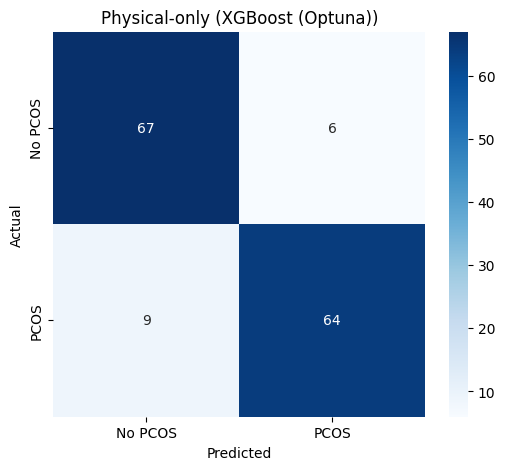

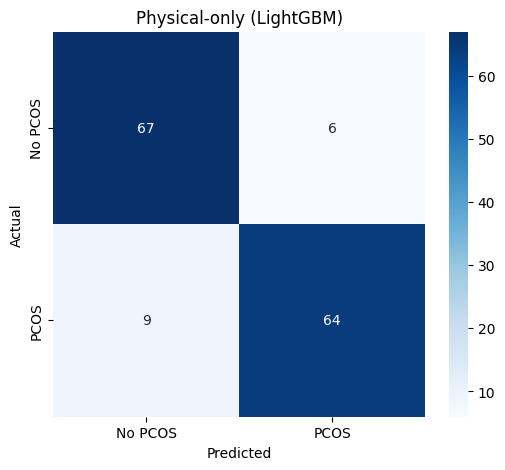

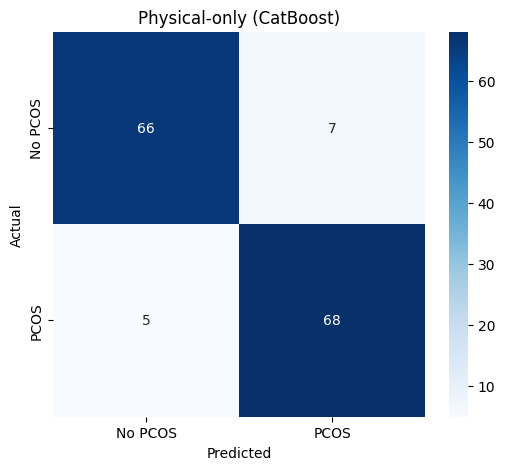

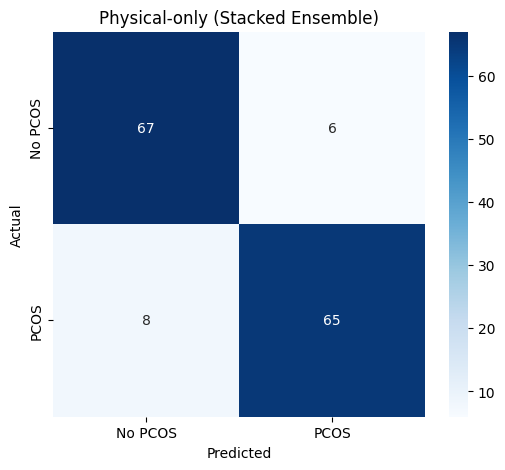

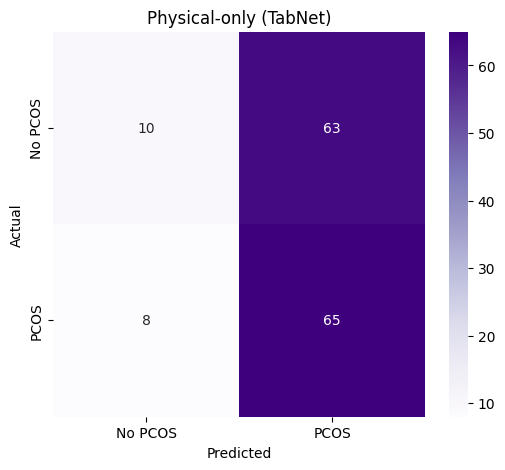

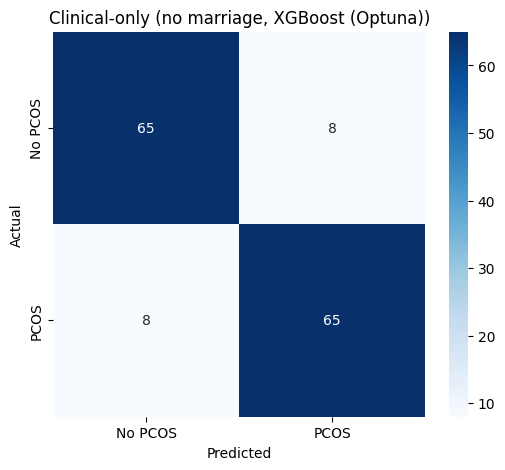

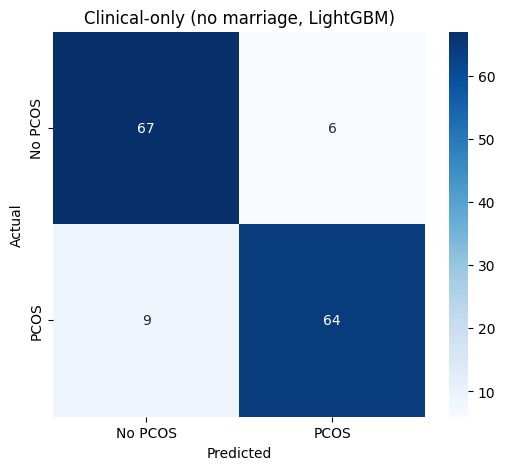

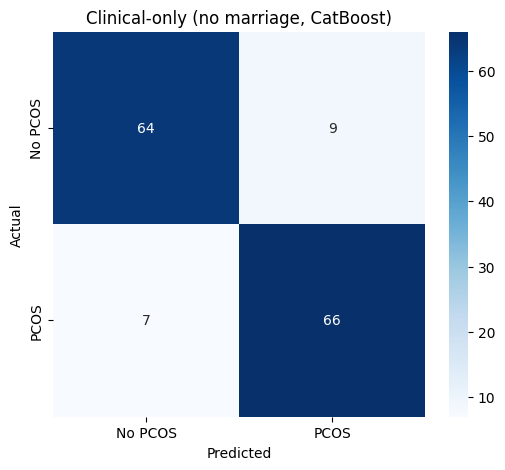

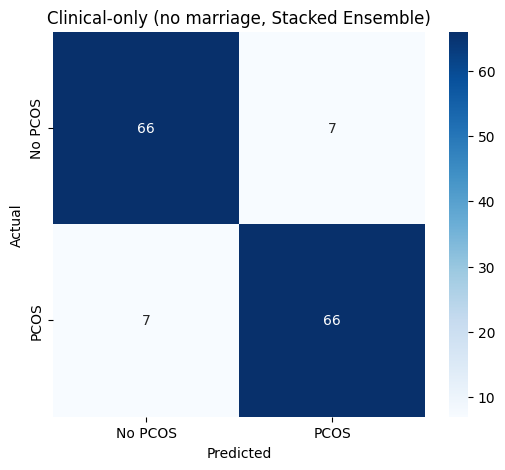

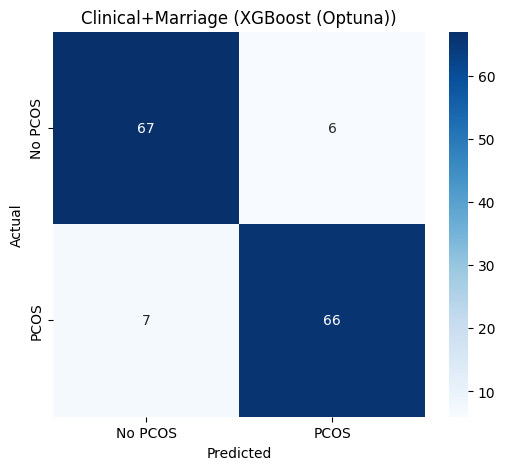

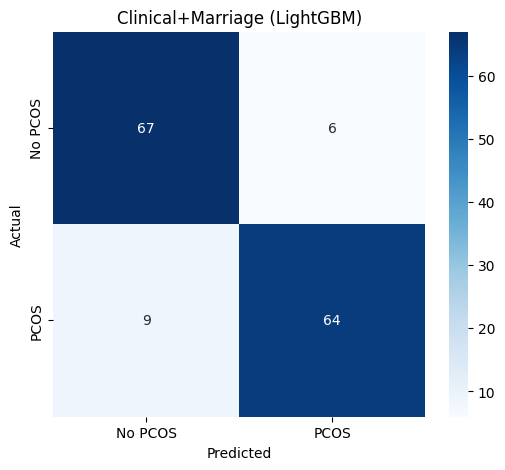

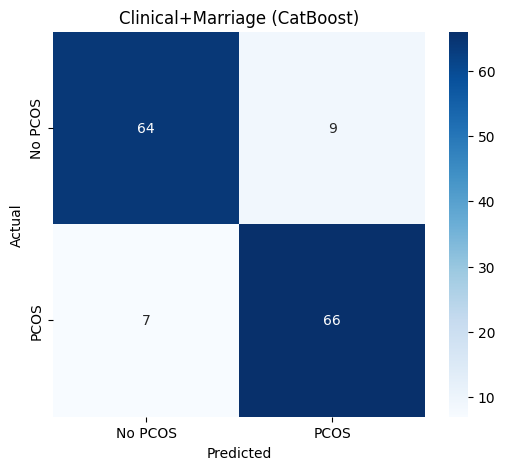

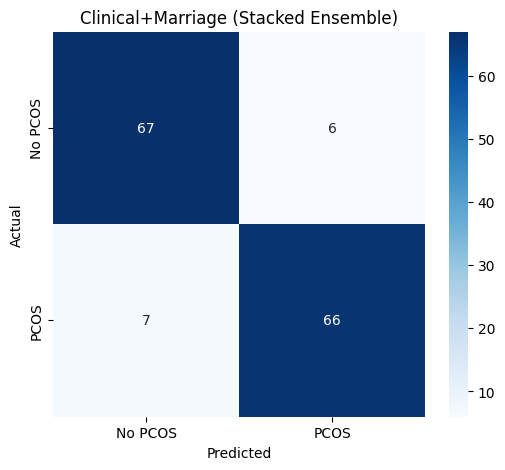

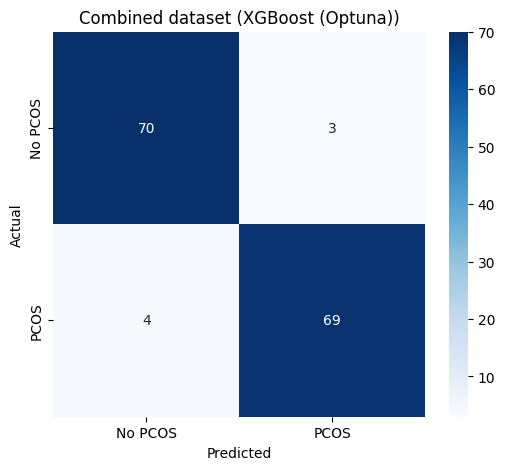

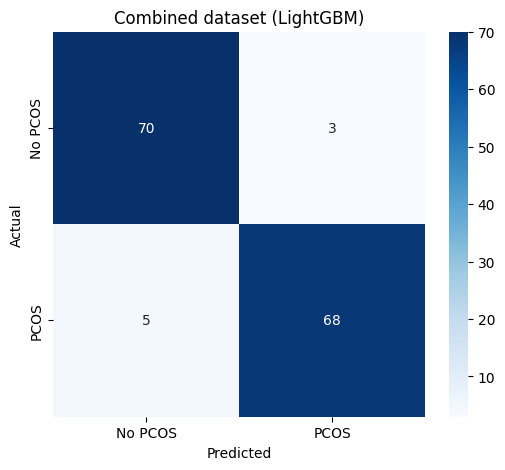

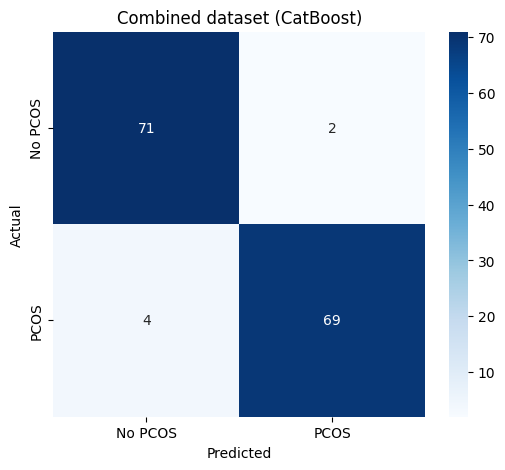

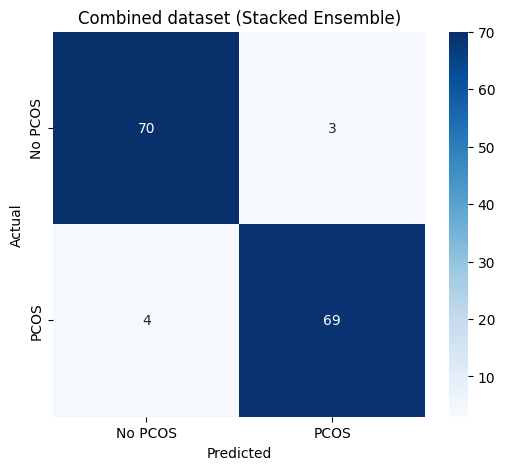

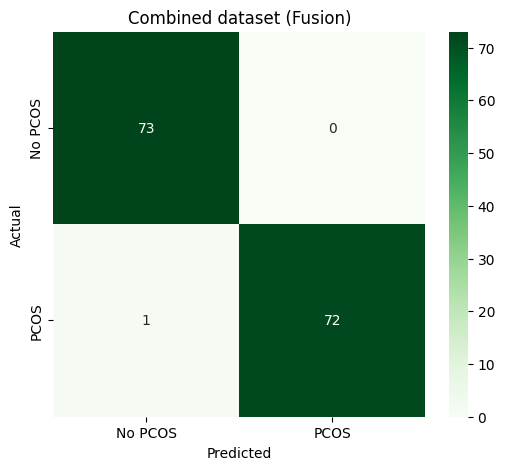

In [12]:
def plot_confusion(y_true, y_pred, title, cmap="Blues"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=["No PCOS","PCOS"],
                yticklabels=["No PCOS","PCOS"])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Physical-only models
for name, model in models_phys.items():
    plot_confusion(y_phys_test, model.predict(X_phys_test), f"Physical-only ({name})")

plot_confusion(y_phys_test, y_pred_tabnet, "Physical-only (TabNet)", cmap="Purples")

# Clinical-only (no marriage)
for name, model in models_clin.items():
    plot_confusion(y_clin_test, model.predict(X_clin_test), f"Clinical-only (no marriage, {name})")

# Clinical-only (with marriage)
for name, model in models_clin_m.items():
    plot_confusion(y_clin_m_test, model.predict(X_clin_m_test), f"Clinical+Marriage ({name})")

# Combined dataset
for name, model in models_comb.items():
    plot_confusion(y_comb_test, model.predict(X_comb_test), f"Combined dataset ({name})")

plot_confusion(y_comb_test, y_pred_fusion, "Combined dataset (Fusion)", cmap="Greens")


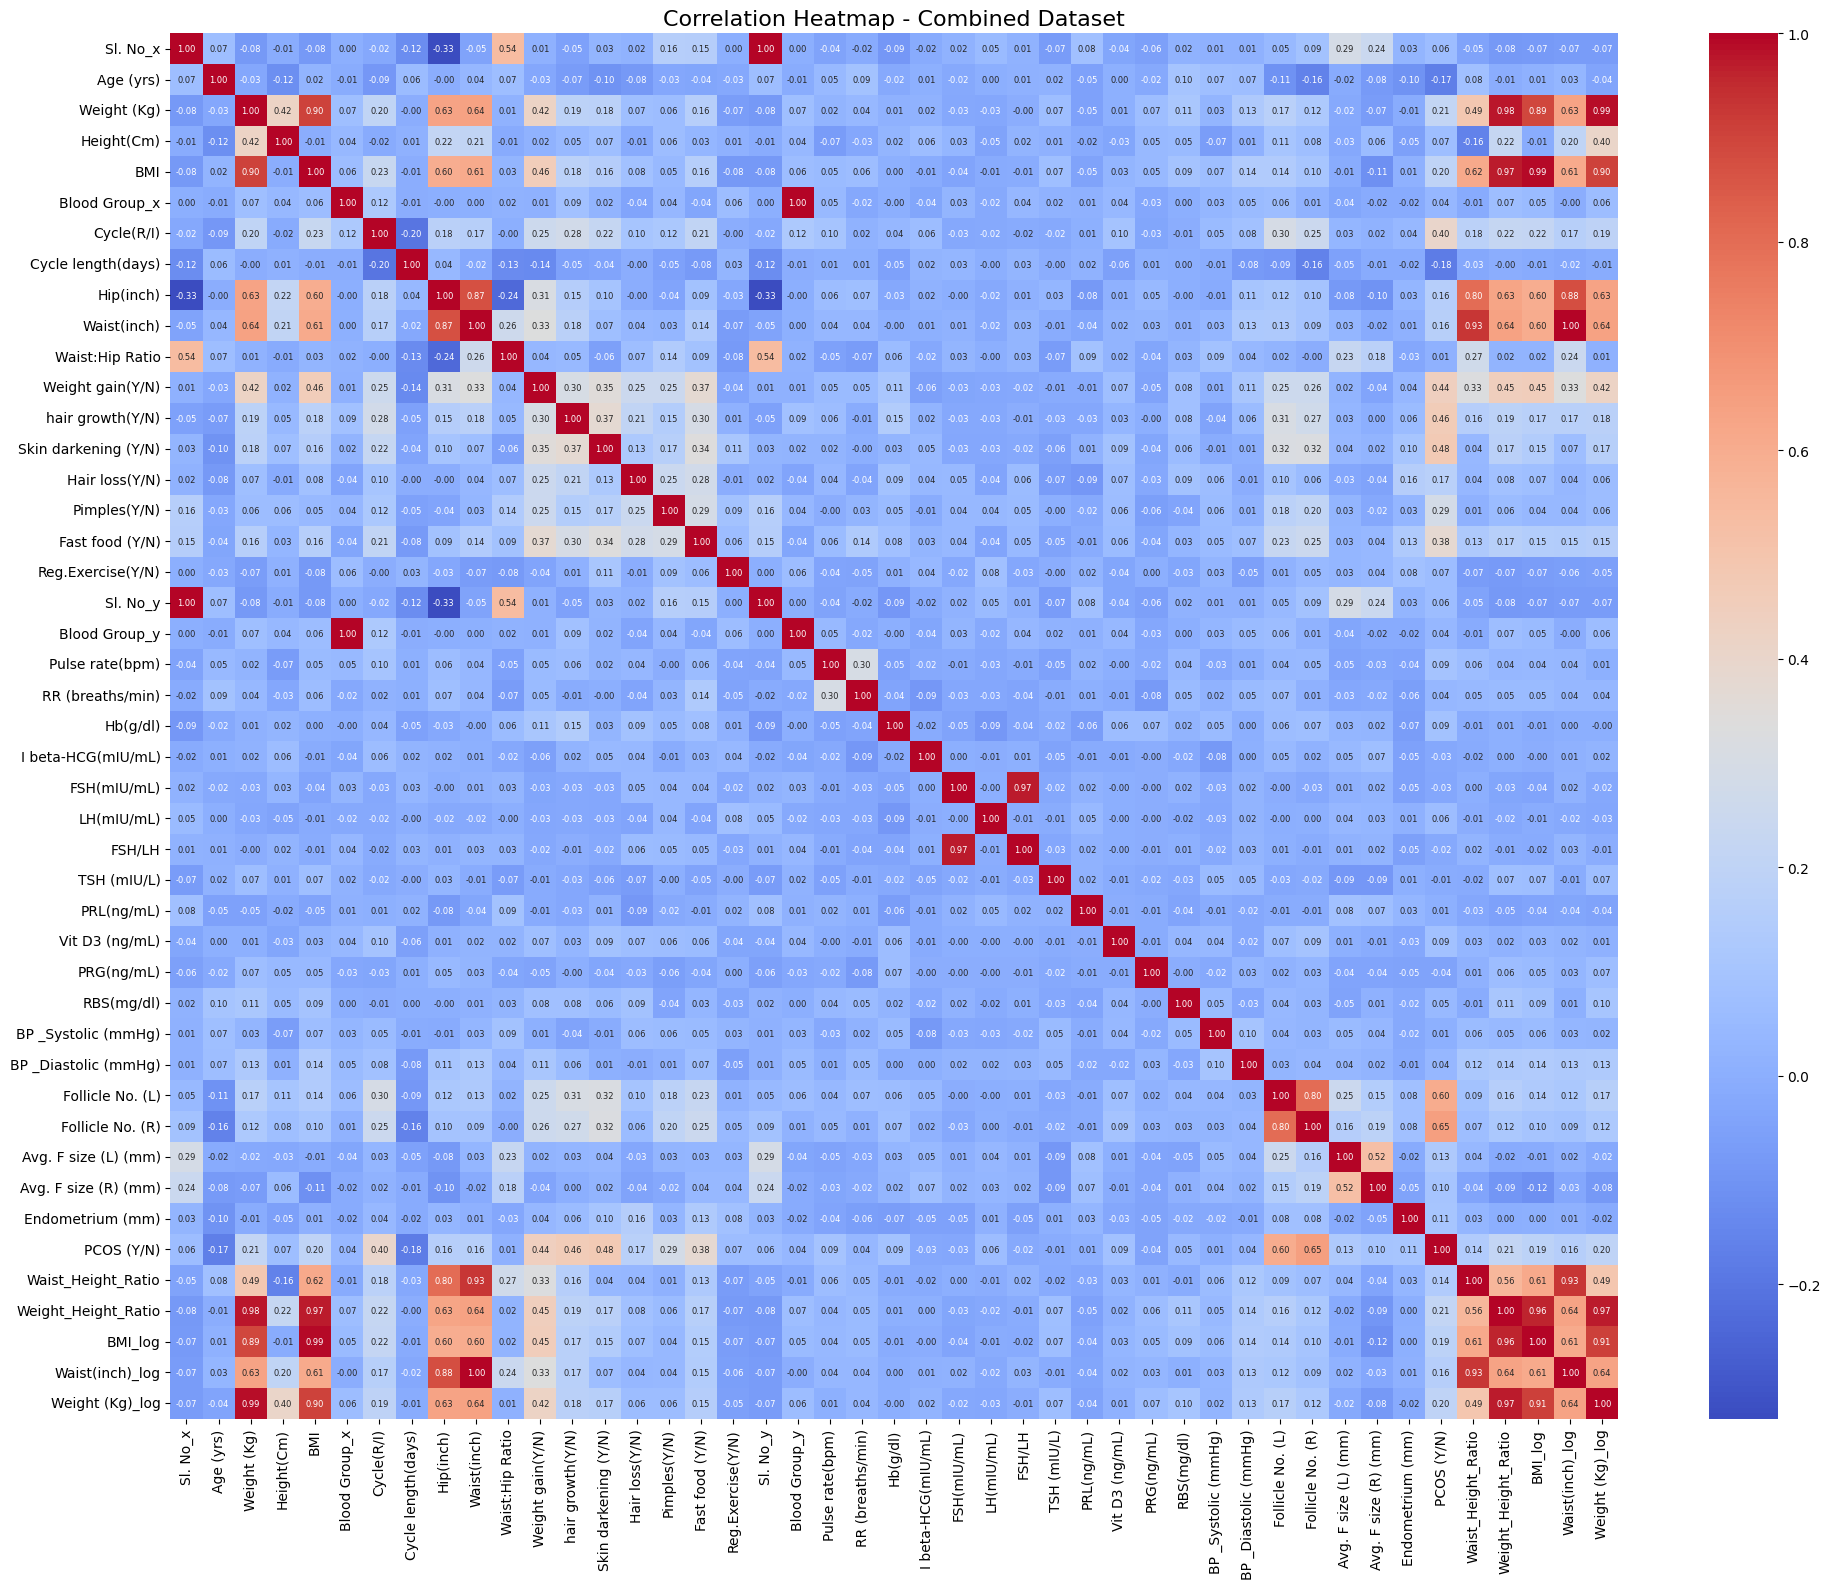

In [13]:
# Select only numeric columns from combined_df
numeric_df = combined_df.select_dtypes(include=[np.number])
numeric_df = numeric_df.apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(20,16))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", annot_kws={"size":6})
plt.title("Correlation Heatmap - Combined Dataset", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


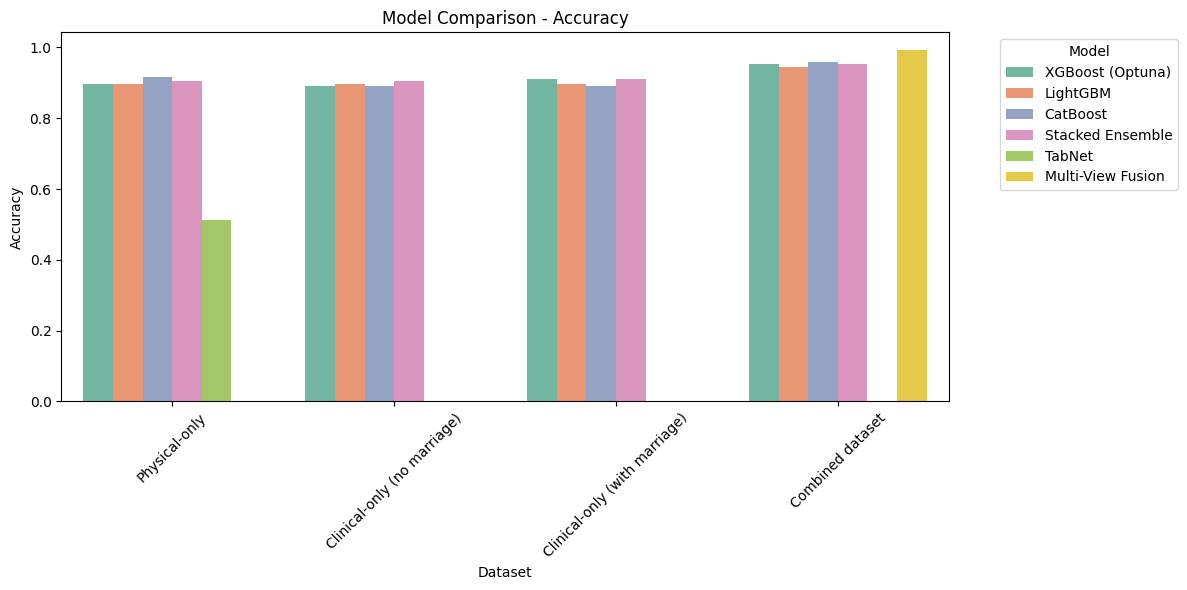

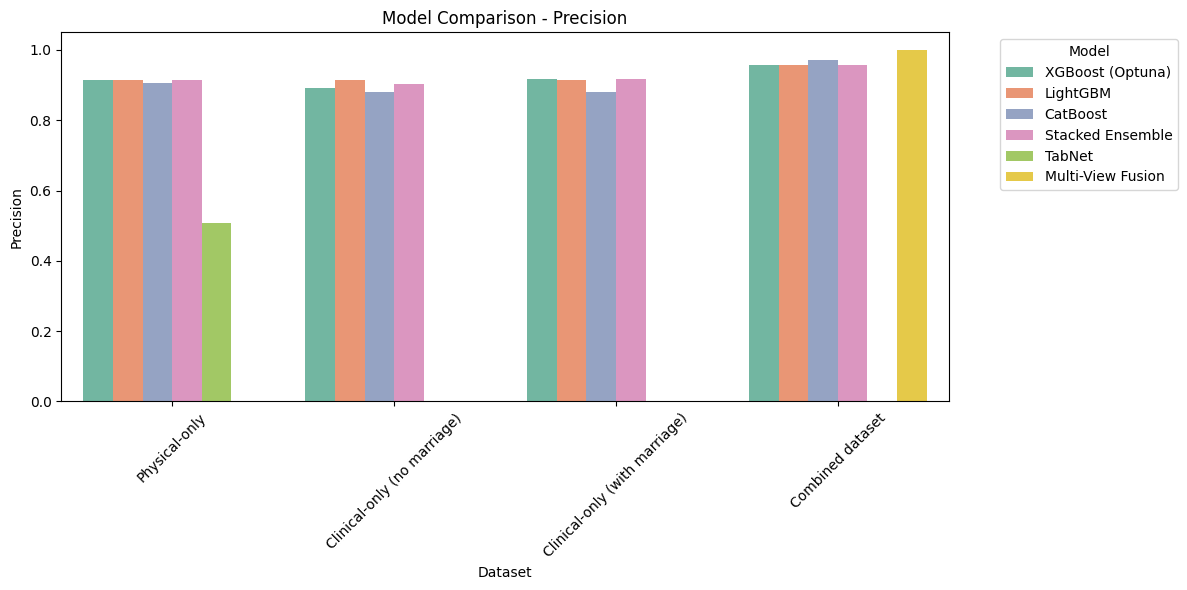

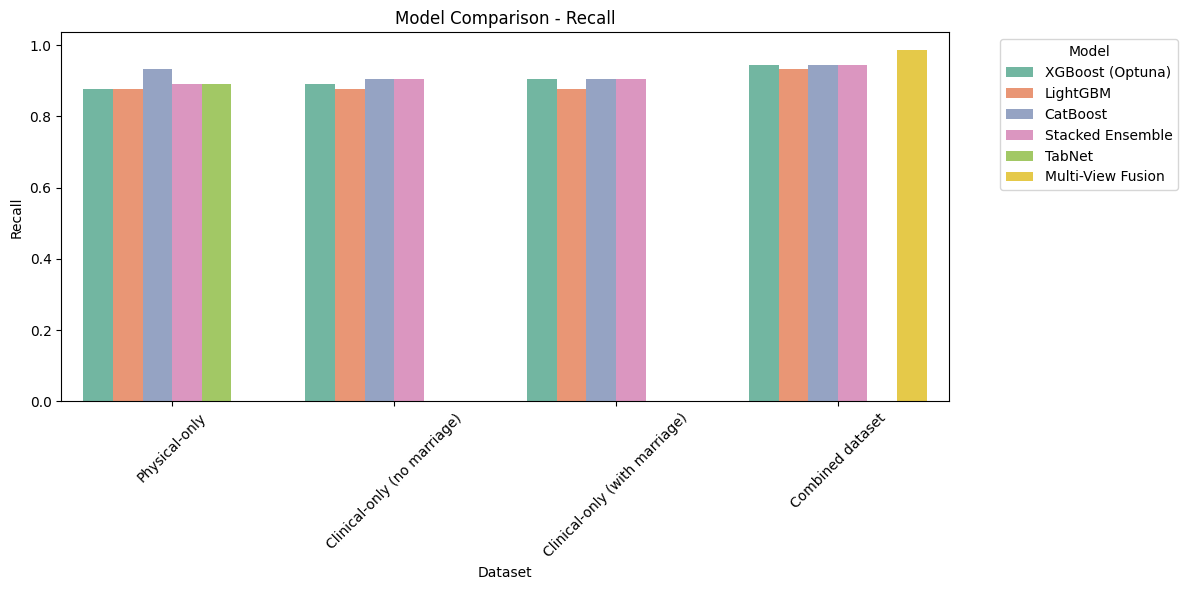

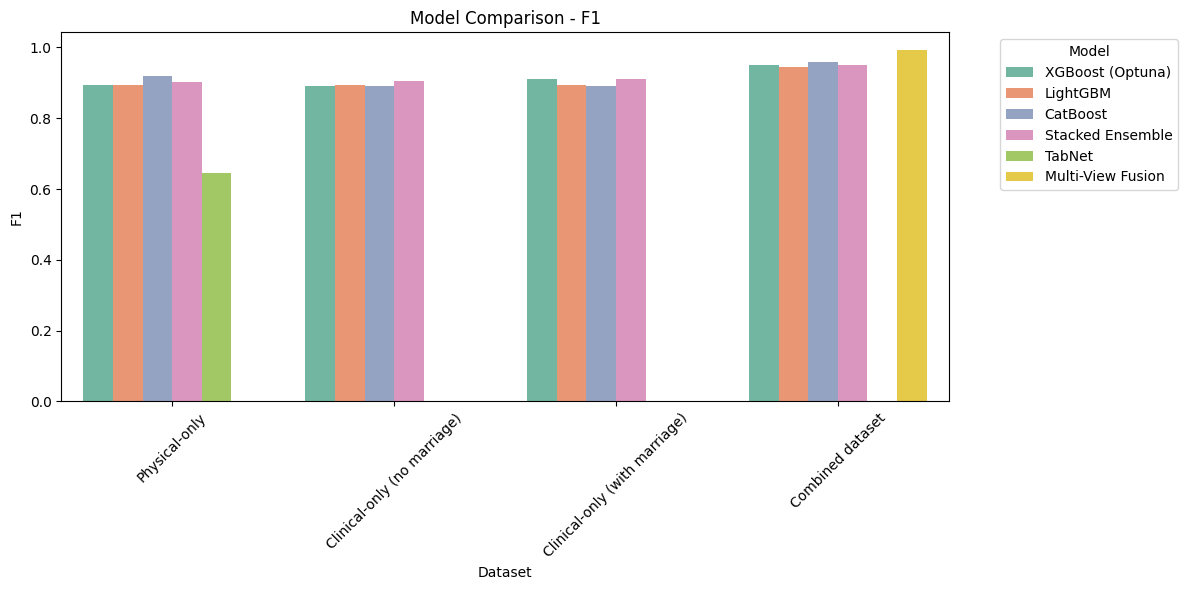

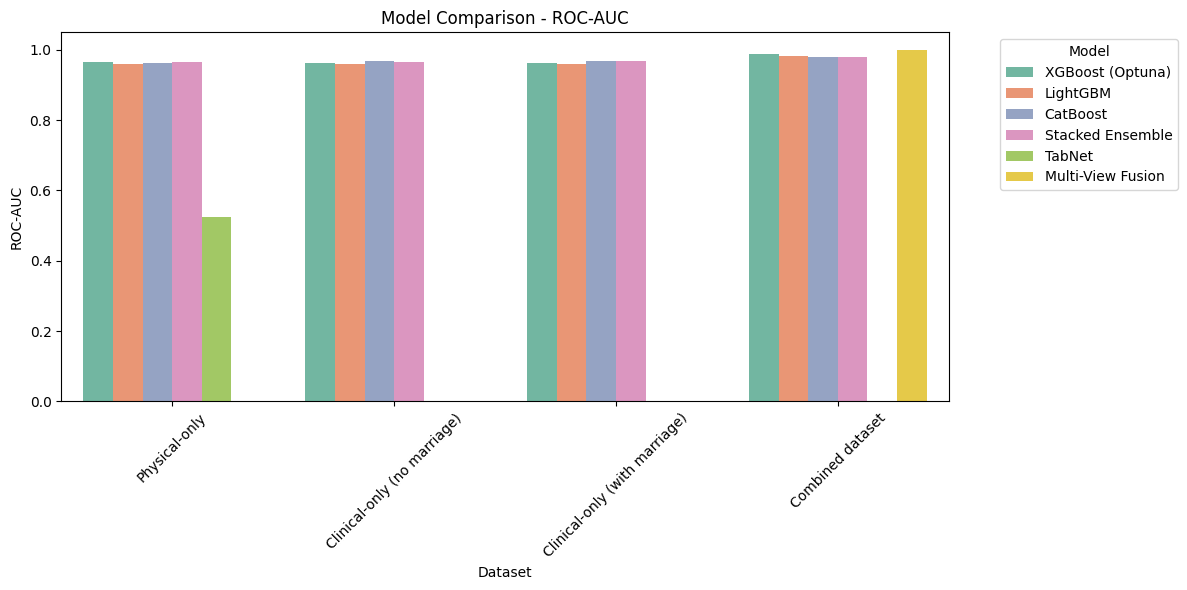

In [14]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

for metric in metrics:
    plt.figure(figsize=(12,6))
    sns.barplot(data=final_results, x="Dataset", y=metric, hue="Model", palette="Set2")
    plt.title(f"Model Comparison - {metric}")
    plt.xticks(rotation=45)
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/model_comparison_{metric.lower()}.png", dpi=300, bbox_inches="tight")
    plt.show()


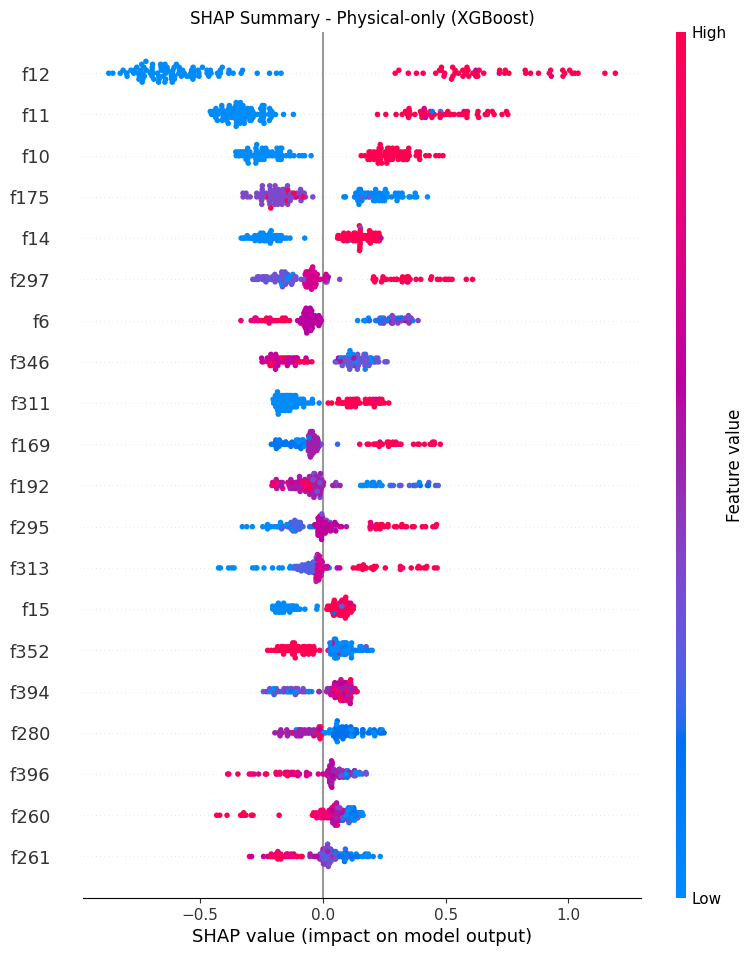

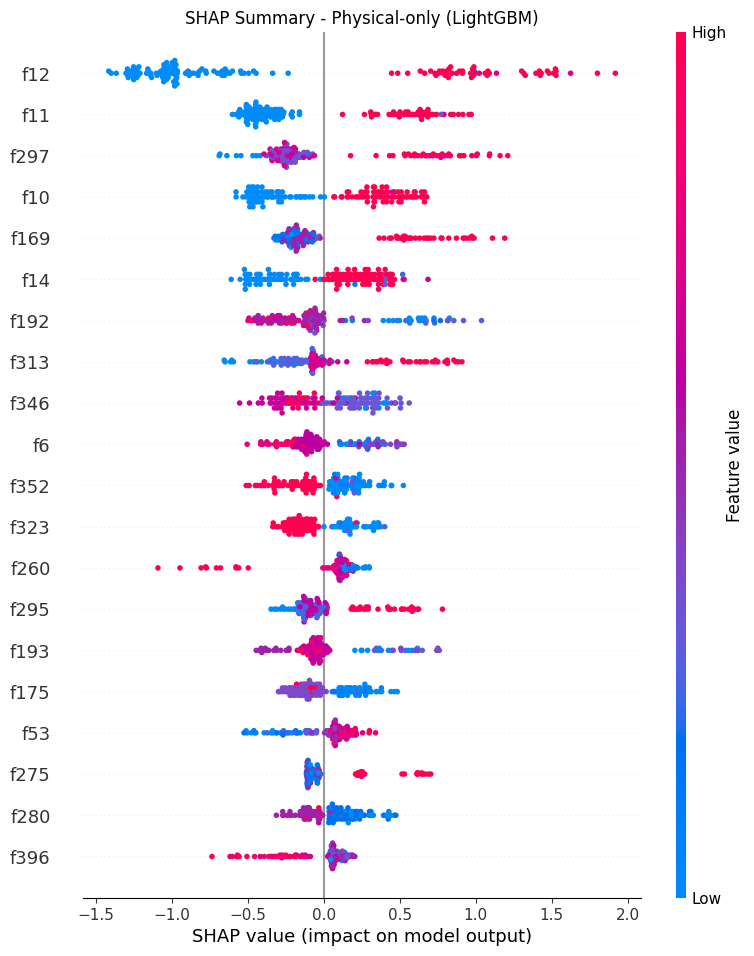

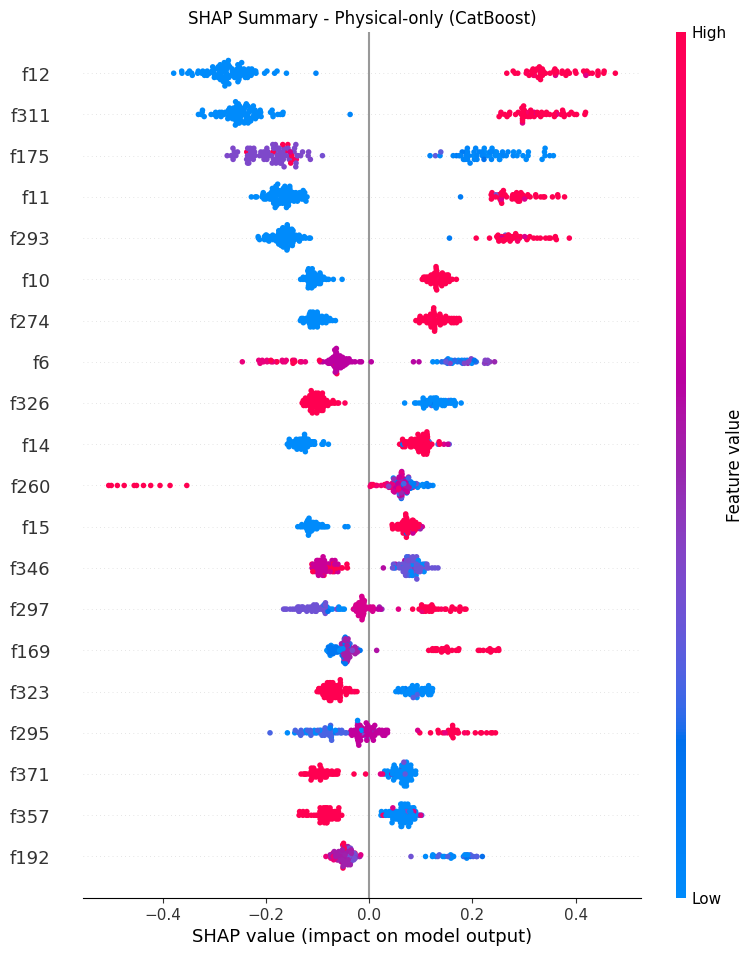

PermutationExplainer explainer: 21it [04:52, 14.62s/it]


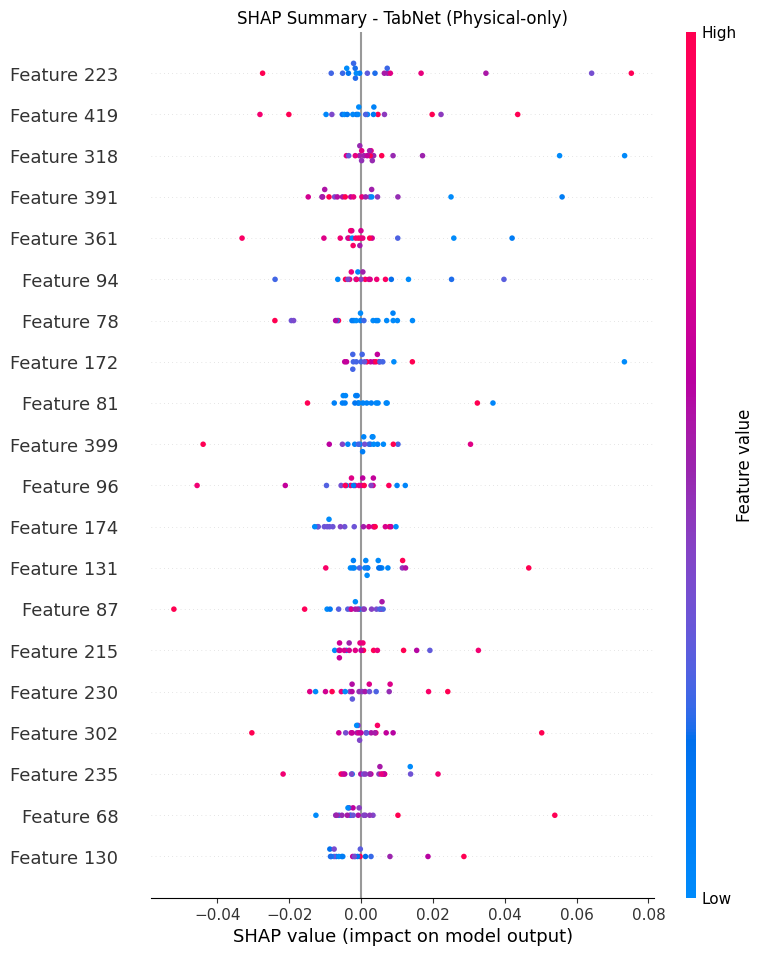

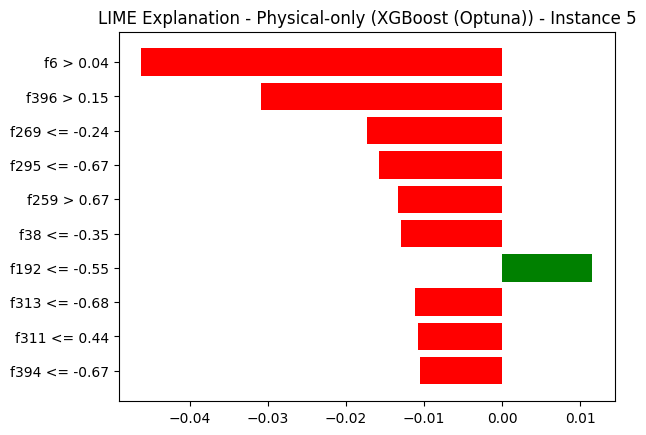

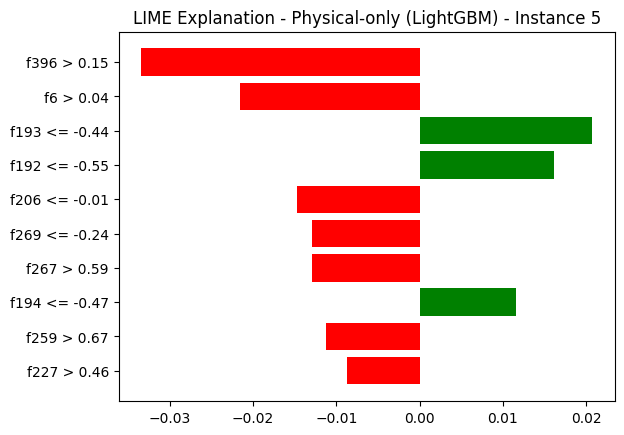

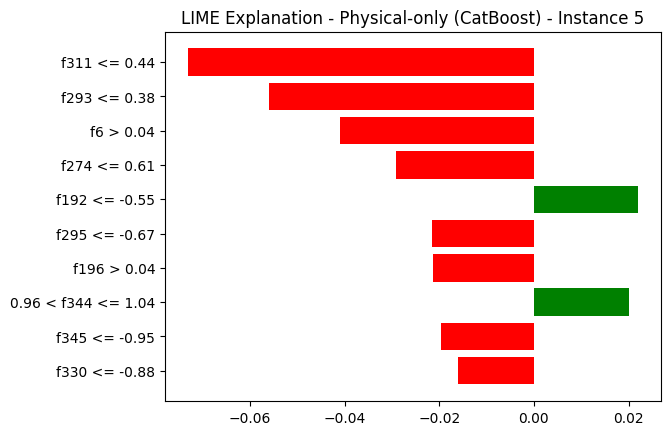

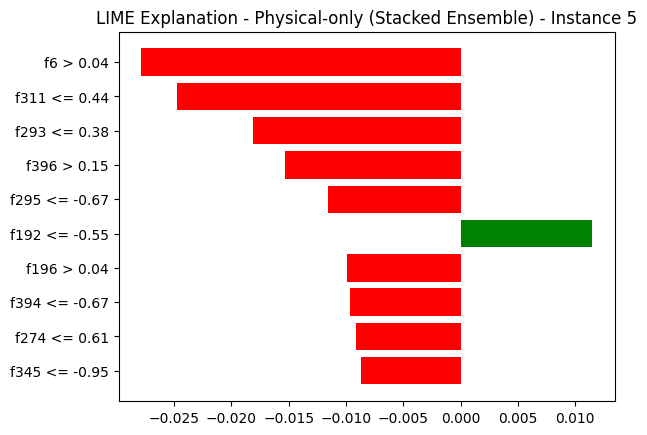

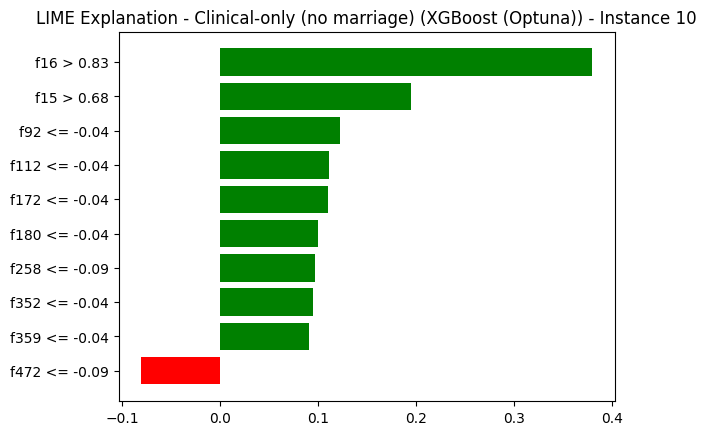

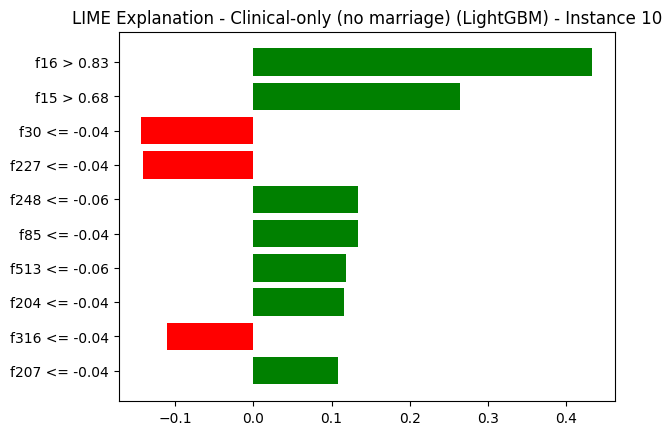

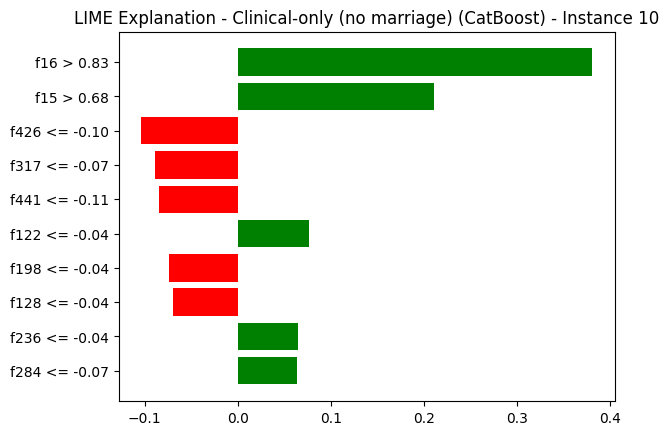

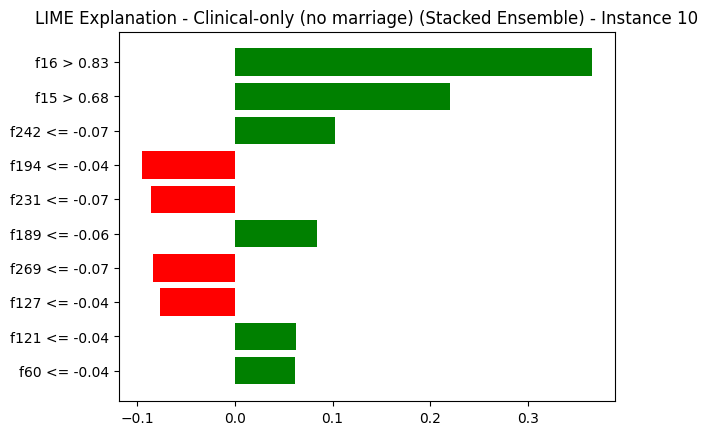

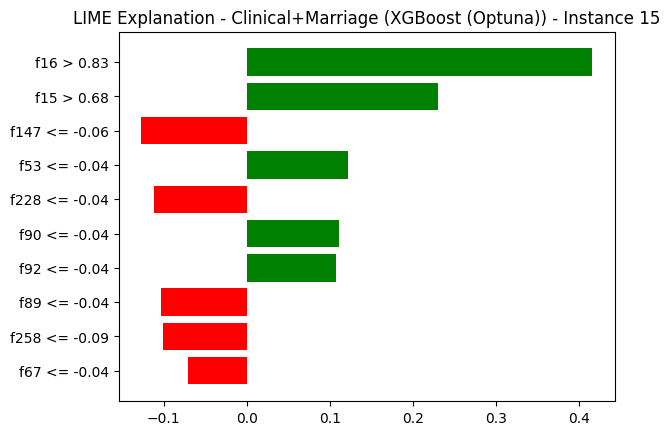

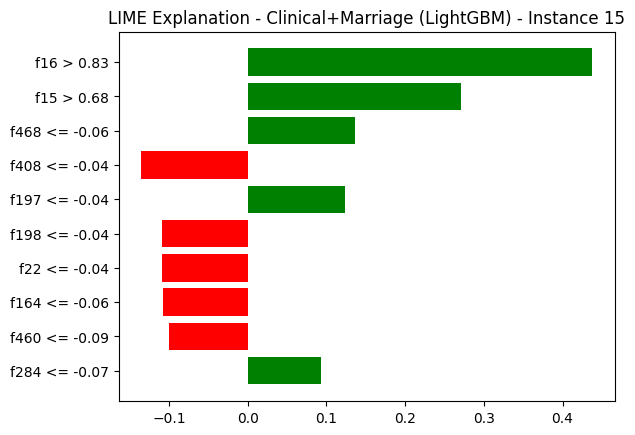

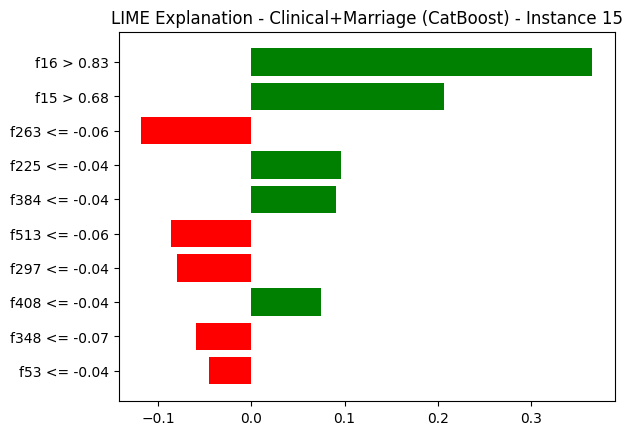

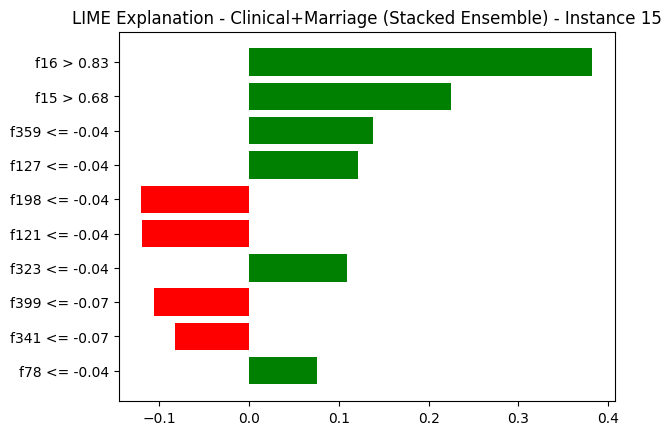

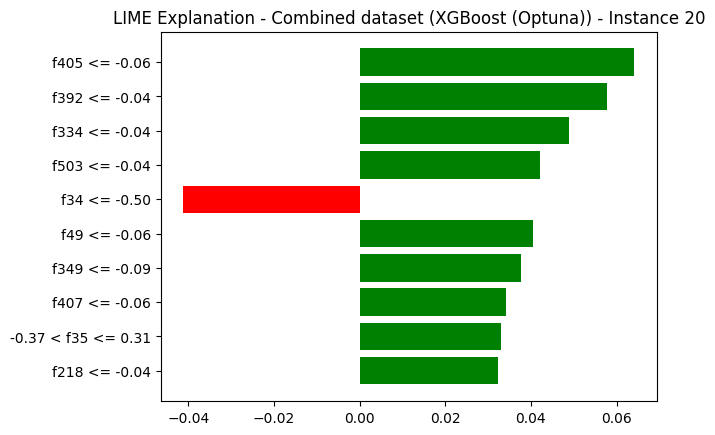

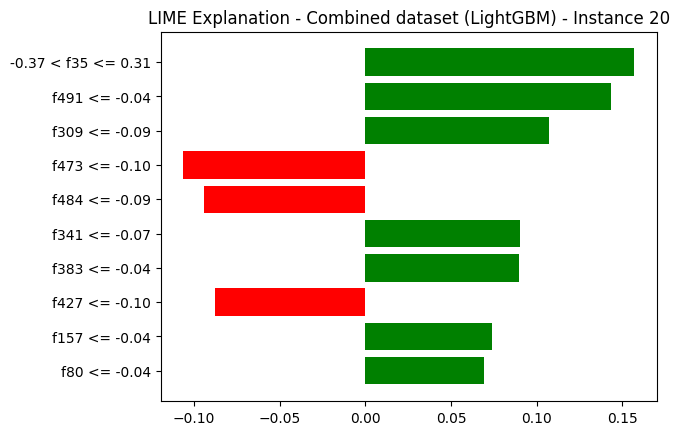

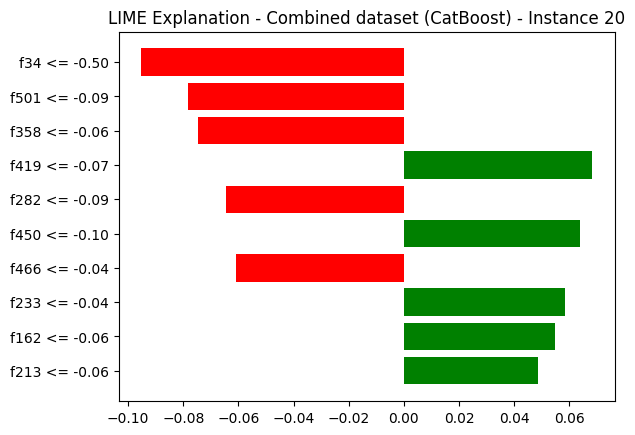

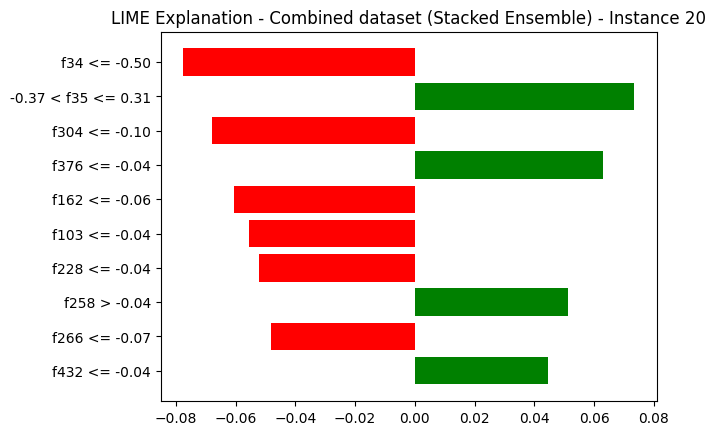

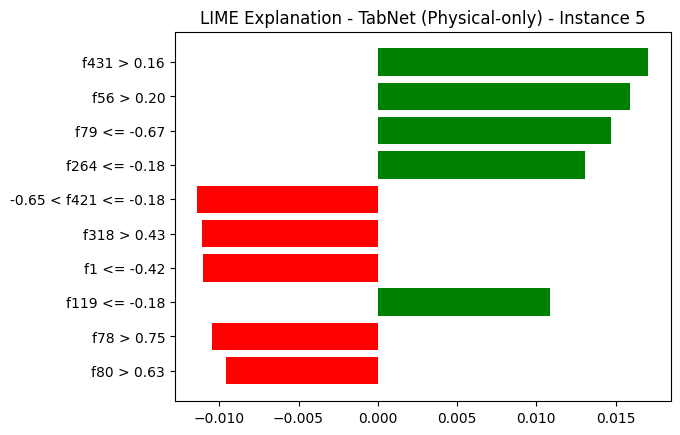

In [15]:
from lime import lime_tabular

# ==============================
# SHAP Explanations (Tree-based + Fusion)
# ==============================
def shap_explain(model, X, feature_names, label):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    shap.summary_plot(shap_values, X, feature_names=feature_names, show=False)
    plt.title(f"SHAP Summary - {label}")
    plt.show()

# Tree-based models
shap_explain(models_phys["XGBoost (Optuna)"], X_phys_test, [f"f{i}" for i in range(X_phys_test.shape[1])], "Physical-only (XGBoost)")
shap_explain(models_phys["LightGBM"], X_phys_test, [f"f{i}" for i in range(X_phys_test.shape[1])], "Physical-only (LightGBM)")
shap_explain(models_phys["CatBoost"], X_phys_test, [f"f{i}" for i in range(X_phys_test.shape[1])], "Physical-only (CatBoost)")

# ==============================
# TabNet SHAP (safe version)
# ==============================
try:
    explainer_tabnet = shap.Explainer(tabnet.predict_proba, X_phys_test[:100])
    shap_values_tabnet = explainer_tabnet(X_phys_test[:20], max_evals=2000)  # increase max_evals
    shap.summary_plot(shap_values_tabnet[:,:,1], X_phys_test[:20], show=False)
    plt.title("SHAP Summary - TabNet (Physical-only)")
    plt.show()
except Exception as e:
    print("TabNet SHAP failed, falling back to LIME:", e)

# ==============================
# LIME Explanations (All models)
# ==============================
def lime_explain_all(models_dict, X_train, X_test, dataset_label, feature_names, class_names=["No PCOS","PCOS"], instance_idx=0):
    explainer = lime_tabular.LimeTabularExplainer(
        training_data=np.array(X_train),
        feature_names=feature_names,
        class_names=class_names,
        mode="classification"
    )
    for name, model in models_dict.items():
        exp = explainer.explain_instance(X_test[instance_idx], model.predict_proba, num_features=10)
        exp.as_pyplot_figure()
        plt.title(f"LIME Explanation - {dataset_label} ({name}) - Instance {instance_idx}")
        plt.show()

# Physical-only models
lime_explain_all(models_phys, X_phys_test, X_phys_test, "Physical-only", [f"f{i}" for i in range(X_phys_test.shape[1])], instance_idx=5)

# Clinical-only (no marriage)
lime_explain_all(models_clin, X_clin_test, X_clin_test, "Clinical-only (no marriage)", [f"f{i}" for i in range(X_clin_test.shape[1])], instance_idx=10)

# Clinical+Marriage
lime_explain_all(models_clin_m, X_clin_m_test, X_clin_m_test, "Clinical+Marriage", [f"f{i}" for i in range(X_clin_m_test.shape[1])], instance_idx=15)

# Combined dataset
lime_explain_all(models_comb, X_comb_test, X_comb_test, "Combined dataset", [f"f{i}" for i in range(X_comb_test.shape[1])], instance_idx=20)

# TabNet LIME (fallback if SHAP fails)
explainer_lime_tabnet = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_phys_test),
    feature_names=[f"f{i}" for i in range(X_phys_test.shape[1])],
    class_names=["No PCOS","PCOS"],
    mode="classification"
)
exp_tabnet = explainer_lime_tabnet.explain_instance(X_phys_test[5], tabnet.predict_proba, num_features=10)
exp_tabnet.as_pyplot_figure()
plt.title("LIME Explanation - TabNet (Physical-only) - Instance 5")
plt.show()


In [16]:
# ==============================
# 1. Generate Encryption Key
# ==============================
key = Fernet.generate_key()
cipher = Fernet(key)

print("Encryption key (store securely!):", key.decode())

Encryption key (store securely!): BpN0ssxP_D2PpkVePdJxxyc3w77tl4n_zSt4Gl4pGAQ=


In [17]:
# ==============================
# 2. Helper Functions
# ==============================
def compute_hash_bytes(data_bytes):
    return hashlib.sha256(data_bytes).hexdigest()

def save_secure_model(model, name, hashes_dict):
    os.makedirs("/kaggle/output", exist_ok=True)
    path = f"/kaggle/working/{name}.pkl"
    
    # Save model normally
    joblib.dump(model, path)
    
    # Encrypt model file
    with open(path,"rb") as f:
        encrypted = cipher.encrypt(f.read())
    secure_path = f"/kaggle/output/{name}_secure.pkl"
    with open(secure_path,"wb") as f:
        f.write(encrypted)
    
    # Compute SHA-256 hash for integrity check
    file_hash = compute_hash_bytes(encrypted)
    hashes_dict[name] = {"path": secure_path, "hash": file_hash}
    print(f"Encrypted model {name} saved securely.")
    return secure_path

def save_secure_data(df, name, hashes_dict):
    path = f"/kaggle/working/{name}.csv"
    df.to_csv(path, index=False)
    
    with open(path,"rb") as f:
        encrypted = cipher.encrypt(f.read())
    secure_path = f"/kaggle/output/{name}_secure.csv"
    with open(secure_path,"wb") as f:
        f.write(encrypted)
    
    file_hash = compute_hash_bytes(encrypted)
    hashes_dict[name] = {"path": secure_path, "hash": file_hash}
    print(f"Encrypted dataset {name} saved securely.")
    return secure_path

def verify_file(path, expected_hash):
    with open(path,"rb") as f:
        file_hash = hashlib.sha256(f.read()).hexdigest()
    if file_hash == expected_hash:
        print(f"Integrity check passed for {path}")
        return True
    else:
        print(f"Integrity check FAILED for {path}")
        return False

In [18]:
# ==============================
# 3. Save Models & Data Securely
# ==============================
hashes = {}

secure_catboost = save_secure_model(models_phys["CatBoost"], "pcos_catboost_phys", hashes)
secure_tabnet   = save_secure_model(tabnet, "pcos_tabnet_phys", hashes)
secure_fusion   = save_secure_model(fusion_model, "pcos_fusion_comb", hashes)

secure_combined = save_secure_data(combined_df, "combined_dataset", hashes)

Encrypted model pcos_catboost_phys saved securely.
Encrypted model pcos_tabnet_phys saved securely.
Encrypted model pcos_fusion_comb saved securely.
Encrypted dataset combined_dataset saved securely.


In [19]:
# ==============================
# 4. Store Hashes in JSON File
# ==============================
hashes_path = "/kaggle/output/security_hashes.json"
with open(hashes_path,"w") as f:
    json.dump(hashes, f, indent=4)

print("All hashes stored in:", hashes_path)

All hashes stored in: /kaggle/output/security_hashes.json


In [20]:
# ==============================
# 5. Example Verification Later
# ==============================
with open(hashes_path,"r") as f:
    stored_hashes = json.load(f)

for name, info in stored_hashes.items():
    verify_file(info["path"], info["hash"])

Integrity check passed for /kaggle/output/pcos_catboost_phys_secure.pkl
Integrity check passed for /kaggle/output/pcos_tabnet_phys_secure.pkl
Integrity check passed for /kaggle/output/pcos_fusion_comb_secure.pkl
Integrity check passed for /kaggle/output/combined_dataset_secure.csv
